In [4]:
import pyvista as pv
import numpy as np

# pv.start_xvfb()

In [5]:
def create_visualization_subplots(mesh, pressure_name='p', n_points=100000):
    """
    Create subplots for visualizing the solid mesh, mesh with pressure, and point cloud with pressure.

    Parameters:
    mesh (pyvista.PolyData): The mesh to visualize.
    pressure_name (str): The name of the pressure field in the mesh's point data.
    n_points (int): Number of points to sample for the point cloud.
    """
    camera_position = [(-11.073024242161921, -5.621499358347753, 5.862225824910342),
                       (1.458462064391673, 0.002314306982062475, 0.6792134746589196),
                       (0.34000174095454166, 0.10379556639001211, 0.9346792479485448)]
    # Sample points from the mesh for the point cloud
    if mesh.n_points > n_points:
        indices = np.random.choice(mesh.n_points, n_points, replace=False)
    else:
        indices = np.arange(mesh.n_points)
    sampled_points = mesh.points[indices]
    sampled_pressures = mesh.point_data[pressure_name][indices]

    # Create a point cloud with pressure data
    point_cloud = pv.PolyData(sampled_points)
    point_cloud[pressure_name] = sampled_pressures

    # Set up the plotter
    plotter = pv.Plotter(shape=(1, 3))

    # Solid mesh visualization
    plotter.subplot(0, 0)
    plotter.add_mesh(mesh, color='lightgrey')
    plotter.add_text('Solid Mesh', position='upper_left')
    plotter.camera_position = camera_position

    # Mesh with pressure visualization
    plotter.subplot(0, 1)
    plotter.add_mesh(mesh, scalars=pressure_name, cmap='jet')
    plotter.add_scalar_bar(title=pressure_name, vertical=True)
    plotter.add_text('Mesh with Pressure', position='upper_left')
    plotter.camera_position = camera_position

    # Point cloud with pressure visualization
    plotter.subplot(0, 2)
    plotter.add_points(point_cloud, scalars=pressure_name, cmap='jet',  clim=(-600, 400), point_size=5)
    plotter.add_scalar_bar(title=pressure_name, vertical=True)
    plotter.add_text('Point Cloud with Pressure', position='upper_left')
    plotter.camera_position = camera_position
    # Show the plot
    plotter.show()


In [6]:
mesh = pv.read('/home/d.ramos/DrivAerNet/PressureVTK/E_S_WWC_WM/E_S_WWC_WM_005.vtk')

In [10]:
sampled_points = mesh.points
sampled_pressures = mesh.point_data['p']
point_cloud = pv.PolyData(sampled_points)
point_cloud['p'] = sampled_pressures
# plot the point cloud
point_cloud.plot(scalars='p', cmap='jet')

sampled_pressures.shape, sampled_points.shape, point_cloud.n_points

: 

In [ ]:
# create_visualization_subplots(mesh, pressure_name='p', n_points=100000)

/home/d.ramos/.conda/envs/cetaceo/lib/python3.11/site-packages/pyvista/plotting/plotter.py:159: UserWarning: 
This system does not appear to be running an xserver.
PyVista will likely segfault when rendering.

Try starting a virtual frame buffer with xvfb, or using
  ``pyvista.start_xvfb()``

  warnings.warn(
/home/d.ramos/.conda/envs/cetaceo/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/d.ramos/.conda/envs/cetaceo/lib/python3.11/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(
2026-04-06 10:34:41.295 (2144.034s) [    700F11D51740]vtkXOpenGLRenderWindow.:456    ERR| vtkXOpenGLRenderWindow (0x22fd7eb0): bad X server connection. DISPLAY=
ERROR:root:bad X server connection. DISPLAY=


: 

## airfrans

In [1]:
import airfrans as af

PATH_TO_SAVING_DIRECTORY = '../data/airfrans'
# af.dataset.download(root = PATH_TO_SAVING_DIRECTORY, file_name = 'Dataset', unzip = True, OpenFOAM = False)

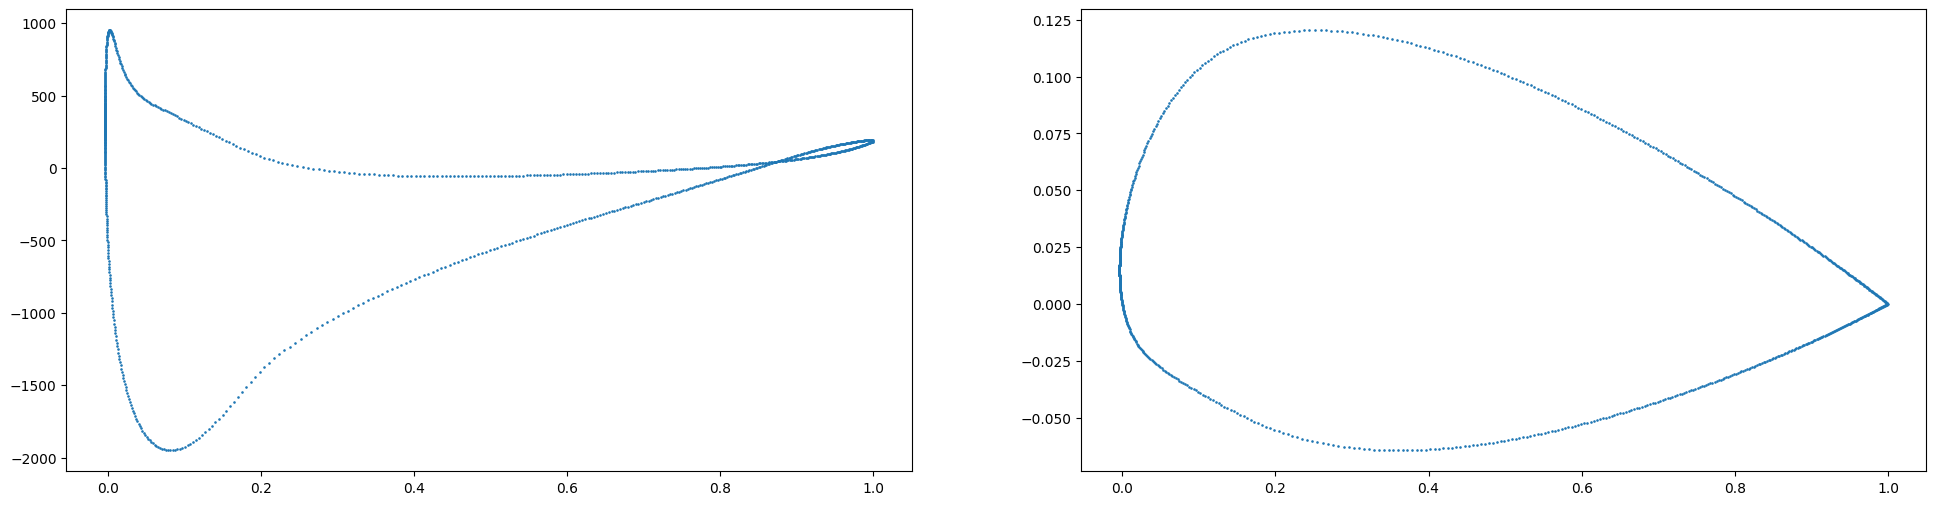

In [1]:
import matplotlib.pyplot as plt
import airfrans as af
import numpy as np

DATA_DIR = '../data/airfrans/Dataset'
simulation = af.Simulation(root = DATA_DIR, name = 'airFoil2D_SST_43.597_5.932_3.551_3.1_1.0_18.252')
fig, ax = plt.subplots(1, 2, figsize = (24, 6))

ax[0].scatter(simulation.position[simulation.surface, 0], simulation.pressure[simulation.surface], s = 0.75)
ax[1].scatter(simulation.position[simulation.surface, 0], simulation.position[simulation.surface, 1], s = 0.75)


In [4]:
dataset_list, dataset_name = af.dataset.load(root = DATA_DIR, task = 'full', train = True)

Loading dataset (task: full, split: train): 100%|██████████| 800/800 [07:26<00:00,  1.79it/s]


In [5]:
dataset_list

[array([[ 4.21555805e+00,  6.31121755e-01,  3.59096884e+01, ...,
          2.85990310e+00,  5.03044717e-10,  0.00000000e+00],
        [ 4.21557093e+00,  6.31108701e-01,  3.59096884e+01, ...,
          2.86004496e+00,  5.04038977e-10,  0.00000000e+00],
        [ 3.99052548e+00,  5.86954355e-01,  3.59096884e+01, ...,
          3.25235939e+00,  3.09837572e-10,  0.00000000e+00],
        ...,
        [-2.13092208e+00, -1.53288102e+00,  3.59096884e+01, ...,
          2.22086563e+01,  3.12786264e-09,  0.00000000e+00],
        [-2.14492369e+00, -1.52218294e+00,  3.59096884e+01, ...,
          2.19026947e+01,  3.12771764e-09,  0.00000000e+00],
        [-2.15894747e+00, -1.51117182e+00,  3.59096884e+01, ...,
          2.15941086e+01,  3.12757775e-09,  0.00000000e+00]]),
 array([[ 4.21687031e+00, -1.99915648e-01,  5.87172837e+01, ...,
          2.49190092e+00,  7.00889854e-03,  0.00000000e+00],
        [ 4.21688938e+00, -1.99935317e-01,  5.87172837e+01, ...,
          2.49188542e+00,  7.00904103e

In [ ]:
import matplotlib.pyplot as plt
import airfrans as af
import os

DATA_DIR = '../data/airfrans/Dataset'

# Get the first 9 folder names
names = sorted([
    f for f in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, f))
])[:9]

fig, axes = plt.subplots(9, 2, figsize=(24, 6 * 9))

for i, name in enumerate(names):
    simulation = af.Simulation(root=DATA_DIR, name=name)

    axes[i, 0].scatter(simulation.position[simulation.surface, 0], simulation.pressure[simulation.surface], s=0.75)
    axes[i, 0].set_title(f'{name}\nPressure')

    axes[i, 1].scatter(simulation.position[simulation.surface, 0], simulation.position[simulation.surface, 1], s=0.75)
    axes[i, 1].set_title(f'{name}\nSurface Shape')

plt.tight_layout()
plt.show()

In [2]:
import os

pressures = [] 
coords = []
conditions = []
for folder in os.listdir(DATA_DIR):
    if os.path.isdir(os.path.join(DATA_DIR, folder)):
        simulation = af.Simulation(root = DATA_DIR, name = folder)
        pressures.append(simulation.pressure[simulation.surface, 0])
        coords.append(simulation.position[simulation.surface])
        conds = np.array([simulation.inlet_velocity, simulation.angle_of_attack])
        conditions.append(conds)

In [3]:
from scipy.spatial import KDTree
import torch
from tqdm import tqdm

def order_airfoil_points(xy: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Reorder airfoil surface points so consecutive points are physically adjacent.
    Uses a greedy nearest-neighbor traversal starting from the trailing edge
    (rightmost x), which is the natural start/end point for airfoil contours.

    Args:
        xy: (N, 2) array of surface coordinates [x, y]

    Returns:
        xy_ordered : (N, 2) reordered coordinates
        order      : (N,)  index permutation  (xy_ordered == xy[order])
    """
    N = len(xy)
    visited = np.zeros(N, dtype=bool)
    order   = np.empty(N, dtype=int)

    # Start from the trailing edge (max x) — natural anchor for airfoils
    current     = int(np.argmax(xy[:, 0]))
    order[0]    = current
    visited[current] = True

    tree = KDTree(xy)

    for i in (range(1, N)):
        # Query enough neighbors to always find an unvisited one
        k = min(20, N - i + 1)
        _, candidates = tree.query(xy[current], k=k + 1)   # +1 because self is included
        for c in candidates[1:]:                            # skip index 0 (self)
            if not visited[c]:
                current = c
                break
        order[i]    = current
        visited[current] = True

    return xy[order], order


# ── Apply to all airfoils and save ──────────────────────────────────────────

ordered_pressures   = []
ordered_coords      = []
ordered_conditions  = conditions  # conditions are per-airfoil, no reordering needed

for p, xy in tqdm(zip(pressures, coords)):
    xy_ord, idx = order_airfoil_points(xy)
    ordered_coords.append(xy_ord)
    ordered_pressures.append(p[idx])   # reorder pressure with the same permutation

torch.save(
    {
        "pressures":  ordered_pressures,
        "coords":     ordered_coords,
        "conditions": ordered_conditions,
    },
    "../data/airfrans/ordered_dataset.pt",
)

print("Saved ordered_dataset.pt")

1000it [00:18, 53.87it/s]


Saved ordered_dataset.pt


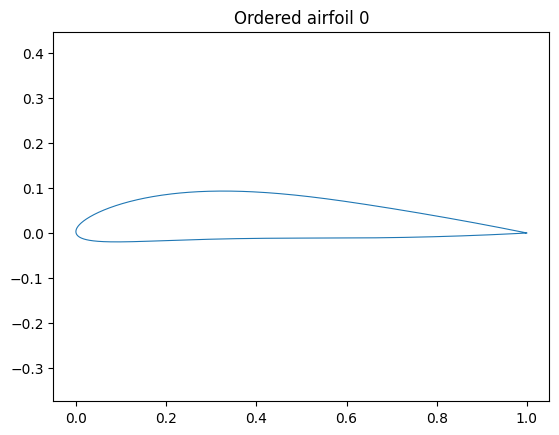

In [5]:
import matplotlib.pyplot as plt

xy = ordered_coords[0]
plt.plot(xy[:, 0], xy[:, 1], ms=2, lw=0.8)
plt.axis('equal')
plt.title("Ordered airfoil 0")
plt.show()

In [ ]:
pressures_arr = np.stack(pressures, axis=1).T
coords_arr = np.stack(coords, axis=0).transpose(0, 2, 1)
conditions_arr = np.stack(conditions, axis=1).T
pressures_arr.shape, coords_arr.shape, conditions_arr.shape

In [15]:
for a, b, c in zip(pressures, coords, conditions):
    print(a.shape, b.shape, c.shape)

(995,) (995, 2) (2,)
(843,) (843, 2) (2,)
(1020,) (1020, 2) (2,)
(1061,) (1061, 2) (2,)
(968,) (968, 2) (2,)
(1005,) (1005, 2) (2,)
(942,) (942, 2) (2,)
(1013,) (1013, 2) (2,)
(956,) (956, 2) (2,)
(988,) (988, 2) (2,)
(1029,) (1029, 2) (2,)
(1072,) (1072, 2) (2,)
(930,) (930, 2) (2,)
(1058,) (1058, 2) (2,)
(1019,) (1019, 2) (2,)
(1165,) (1165, 2) (2,)
(1019,) (1019, 2) (2,)
(996,) (996, 2) (2,)
(995,) (995, 2) (2,)
(992,) (992, 2) (2,)
(1008,) (1008, 2) (2,)
(1063,) (1063, 2) (2,)
(1018,) (1018, 2) (2,)
(1020,) (1020, 2) (2,)
(1026,) (1026, 2) (2,)
(997,) (997, 2) (2,)
(902,) (902, 2) (2,)
(1023,) (1023, 2) (2,)
(1007,) (1007, 2) (2,)
(1015,) (1015, 2) (2,)
(1032,) (1032, 2) (2,)
(925,) (925, 2) (2,)
(971,) (971, 2) (2,)
(927,) (927, 2) (2,)
(1013,) (1013, 2) (2,)
(1063,) (1063, 2) (2,)
(1022,) (1022, 2) (2,)
(993,) (993, 2) (2,)
(1040,) (1040, 2) (2,)
(975,) (975, 2) (2,)
(1011,) (1011, 2) (2,)
(918,) (918, 2) (2,)
(1013,) (1013, 2) (2,)
(1020,) (1020, 2) (2,)
(934,) (934, 2) (2,)
(99

In [16]:
import torch
torch.save({"pressures": pressures, "coords": coords, "conditions": conditions},
           "../data/airfrans/processed_data.pt")

In [ ]:
np.savez('../data/airfrans/processed_data.npz', pressures=pressures_arr, coords=coords_arr, conditions=conditions_arr)

In [14]:
np.concatenate([np.array([1,2,3]), np.array([4,5])])  # → array([1,2,3,4,5])

array([1, 2, 3, 4, 5])